# Half-Life of Mean Reversion

This notebook estimates the half-life of mean reversion from a simple regression of $\Delta y_t$ on $y_{t-1}$.

The working approximation is:

$$
\Delta y_t = \lambda y_{t-1} + c + \varepsilon_t,
$$

and the half-life is:

$$
\text{half-life} = -\frac{\log 2}{\lambda}.
$$

This only makes economic sense when $\lambda < 0$.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [ ]:
def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )

repo_root = find_repo_root()
fixture_path = repo_root / "fixtures/crypto/crypto_daily_close.csv"

close_matrix = pd.read_csv(fixture_path, parse_dates=["date"]).set_index("date").sort_index()
close_matrix = close_matrix.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbol = "BTCUSDT"
if symbol not in close_matrix:
    raise ValueError(f"Fixture is missing required symbol: {symbol}")

close = close_matrix[symbol].dropna()
close.name = "close"
log_price = np.log(close)

# Use a detrended series so the half-life describes pullback to a local mean
# rather than the raw non-stationary crypto price itself.
rolling_mean = log_price.rolling(30).mean()
mean_reverting_series = (log_price - rolling_mean).dropna()

mean_reverting_series.tail()


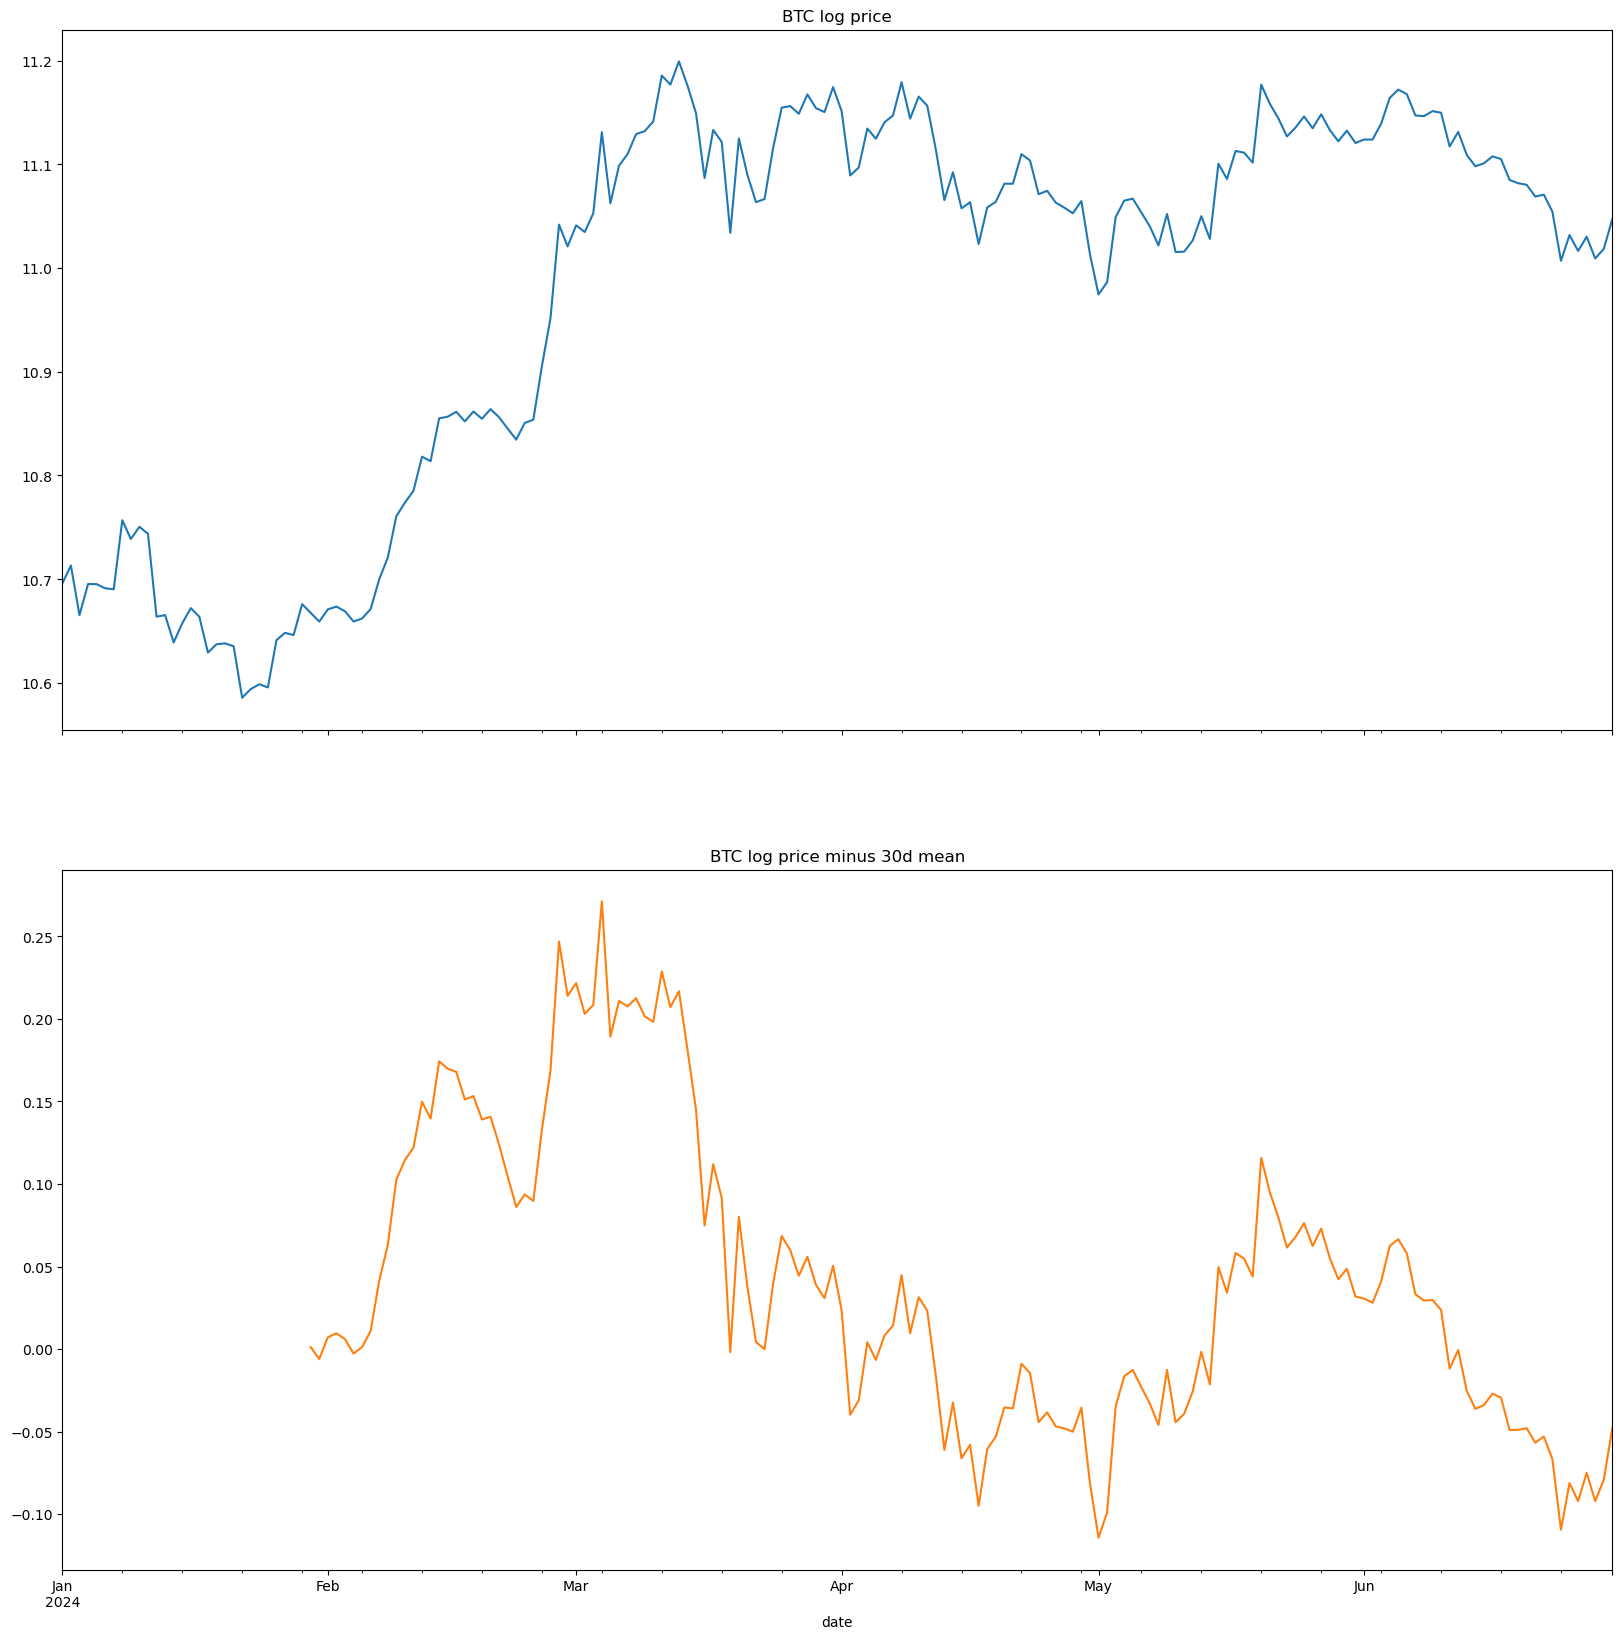

In [3]:
pd.concat(
    {
        "BTC log price": log_price,
        "BTC log price - 30d mean": mean_reverting_series,
    },
    axis=1,
).plot(
    subplots=True,
    figsize=(20, 20),
    title=["BTC log price", "BTC log price minus 30d mean"],
    layout=(2, 1),
    legend=False,
);

In [4]:
def estimate_half_life(series: pd.Series) -> tuple[pd.Series, pd.DataFrame]:
    y = pd.Series(series).dropna()
    lagged = y.shift(1)
    delta = y.diff()

    reg_df = pd.DataFrame({"lagged": lagged, "delta": delta}).dropna()
    x = np.column_stack([np.ones(len(reg_df)), reg_df["lagged"].to_numpy()])
    y_dep = reg_df["delta"].to_numpy()

    intercept, lambda_hat = np.linalg.lstsq(x, y_dep, rcond=None)[0]

    if lambda_hat >= 0:
        half_life = np.nan
        verdict = "not mean reverting"
    else:
        half_life = -np.log(2) / lambda_hat
        verdict = "mean reverting"

    summary = pd.Series(
        {
            "intercept": intercept,
            "lambda": lambda_hat,
            "half_life_days": half_life,
            "verdict": verdict,
            "observations": len(reg_df),
        }
    )
    return summary, reg_df

In [5]:
half_life_summary, reg_df = estimate_half_life(mean_reverting_series)

half_life_df = half_life_summary.to_frame(name="value")
half_life_df

,value
intercept,0.001550
lambda,-0.046533
half_life_days,14.895718
verdict,mean reverting
observations,152


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(reg_df["lagged"], reg_df["delta"], alpha=0.65, color="tab:blue", label="daily observations")

x_grid = np.linspace(reg_df["lagged"].min(), reg_df["lagged"].max(), 100)
y_hat = half_life_summary["intercept"] + half_life_summary["lambda"] * x_grid
ax.plot(x_grid, y_hat, color="tab:red", linewidth=2, label="estimated pullback slope")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Half-life regression: next-day change versus lagged deviation")
ax.set_xlabel("Lagged deviation from 30d mean")
ax.set_ylabel("Next-day change in deviation")
ax.legend()
plt.tight_layout();


In [ ]:
rolling_half_life = (
    mean_reverting_series
    .rolling(90)
    .apply(lambda window: estimate_half_life(pd.Series(window))[0]["half_life_days"], raw=False)
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 4))
rolling_half_life.clip(upper=60).plot(ax=ax, color="tab:green", linewidth=2)
ax.axhline(half_life_summary["half_life_days"], color="black", linestyle="--", linewidth=1, label="full-sample estimate")
ax.set_title("Rolling 90-day half-life estimate, capped at 60 days")
ax.set_ylabel("half-life days")
ax.legend()
plt.tight_layout();


In [6]:
if pd.notna(half_life_summary["half_life_days"]):
    half_life_days = float(half_life_summary["half_life_days"])
    lookback_df = pd.DataFrame(
        {
            "rule": [
                "half-life",
                "rounded half-life",
                "2 x half-life",
            ],
            "days": [
                half_life_days,
                round(half_life_days),
                round(2 * half_life_days),
            ],
        }
    )
else:
    lookback_df = pd.DataFrame(
        {
            "rule": ["half-life unavailable"],
            "days": [np.nan],
        }
    )

lookback_df

,rule,days
0,half-life,14.895718
1,rounded half-life,15.000000
2,2 x half-life,30.000000


## Interpretation

Half-life turns the regression coefficient into trading time. A negative `λ` gives a finite half-life. A very small negative `λ` gives a very long half-life, which usually means the pullback is too slow to be useful for a short-horizon strategy.

## Visualizing Half-Life

The chart below picks one local peak in the detrended series and marks the dates that are about one and two half-lives later. If the series follows mean reversion closely, the distance from zero should shrink to roughly one-half of the starting deviation after one half-life, and to roughly one-quarter after two half-lives.

,date,deviation,abs_deviation,reference,fraction_of_start_abs_dev
0,2024-03-04,0.271217,0.271217,start,1.000000
1,2024-03-19,-0.001866,0.001866,~1 half-life later,0.006881
2,2024-04-03,-0.031061,0.031061,~2 half-lives later,0.114523


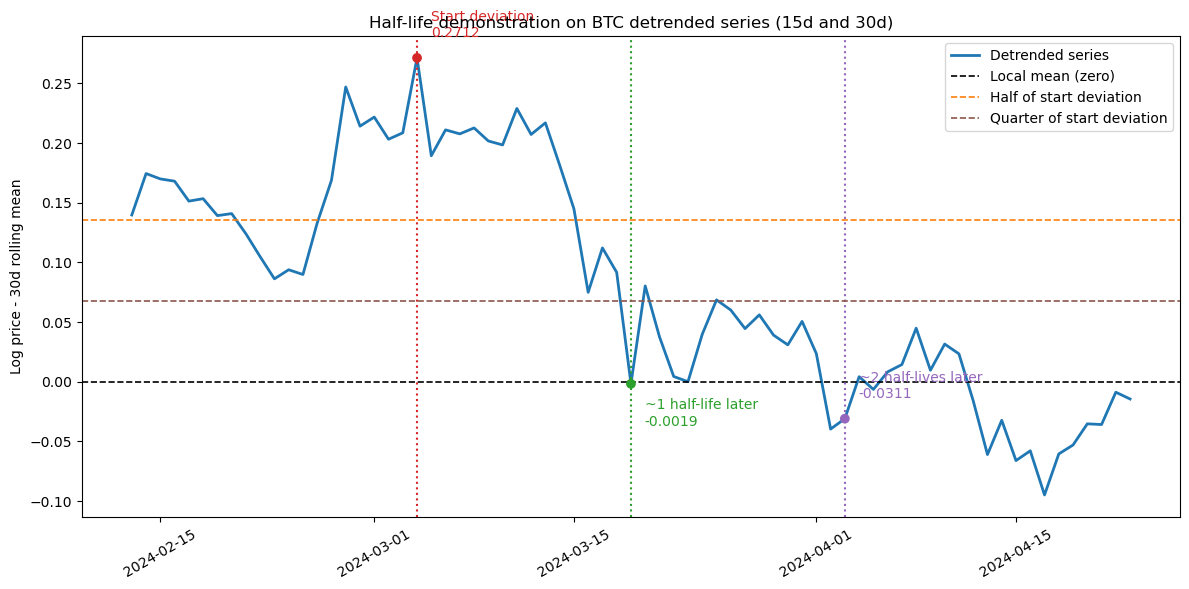

In [7]:
if pd.isna(half_life_summary["half_life_days"]):
    raise ValueError("Half-life is unavailable because the series is not mean reverting.")

half_life_days = float(half_life_summary["half_life_days"])
half_life_steps = max(1, round(half_life_days))
two_half_life_steps = max(1, round(2 * half_life_days))

# Pick a large local deviation so the half-life interpretation is visually clear.
start_idx = mean_reverting_series.abs().idxmax()
start_pos = mean_reverting_series.index.get_loc(start_idx)

window_before = 20
window_after = max(two_half_life_steps + 20, 50)
window_start = max(0, start_pos - window_before)
window_end = min(len(mean_reverting_series), start_pos + window_after + 1)
window_series = mean_reverting_series.iloc[window_start:window_end]

target_pos_1 = min(start_pos + half_life_steps, len(mean_reverting_series) - 1)
target_pos_2 = min(start_pos + two_half_life_steps, len(mean_reverting_series) - 1)
target_idx_1 = mean_reverting_series.index[target_pos_1]
target_idx_2 = mean_reverting_series.index[target_pos_2]

start_deviation = mean_reverting_series.loc[start_idx]
target_deviation_1 = mean_reverting_series.loc[target_idx_1]
target_deviation_2 = mean_reverting_series.loc[target_idx_2]
half_deviation = start_deviation / 2
quarter_deviation = start_deviation / 4

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(window_series.index, window_series.values, color="tab:blue", linewidth=2, label="Detrended series")
ax.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Local mean (zero)")
ax.axvline(start_idx, color="tab:red", linestyle=":", linewidth=1.5)
ax.axvline(target_idx_1, color="tab:green", linestyle=":", linewidth=1.5)
ax.axvline(target_idx_2, color="tab:purple", linestyle=":", linewidth=1.5)
ax.scatter(
    [start_idx, target_idx_1, target_idx_2],
    [start_deviation, target_deviation_1, target_deviation_2],
    color=["tab:red", "tab:green", "tab:purple"],
    zorder=5,
)
ax.axhline(half_deviation, color="tab:orange", linestyle="--", linewidth=1.2, label="Half of start deviation")
ax.axhline(quarter_deviation, color="tab:brown", linestyle="--", linewidth=1.2, label="Quarter of start deviation")

ax.annotate(
    f"Start deviation\n{start_deviation:.4f}",
    xy=(start_idx, start_deviation),
    xytext=(10, 15),
    textcoords="offset points",
    color="tab:red",
    fontsize=10,
)
ax.annotate(
    f"~1 half-life later\n{target_deviation_1:.4f}",
    xy=(target_idx_1, target_deviation_1),
    xytext=(10, -30),
    textcoords="offset points",
    color="tab:green",
    fontsize=10,
)
ax.annotate(
    f"~2 half-lives later\n{target_deviation_2:.4f}",
    xy=(target_idx_2, target_deviation_2),
    xytext=(10, 15),
    textcoords="offset points",
    color="tab:purple",
    fontsize=10,
)

ax.set_title(
    f"Half-life demonstration on BTC detrended series ({half_life_steps}d and {two_half_life_steps}d)"
)
ax.set_ylabel("Log price - 30d rolling mean")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()

demo_df = pd.DataFrame(
    {
        "date": [start_idx, target_idx_1, target_idx_2],
        "deviation": [start_deviation, target_deviation_1, target_deviation_2],
        "abs_deviation": [abs(start_deviation), abs(target_deviation_1), abs(target_deviation_2)],
        "reference": ["start", "~1 half-life later", "~2 half-lives later"],
    }
)
demo_df["fraction_of_start_abs_dev"] = demo_df["abs_deviation"] / abs(start_deviation)

display(demo_df)
plt.show()
